# 15. Reporting Statistical Recommendations for Real Stakeholders

Statistical work does not end when the model converges, the interval is computed, or the posterior is sampled. It ends when someone can make a better decision because the analysis was translated into **action, magnitude, uncertainty, assumptions, and next steps**. We show how to turn technically correct analysis into recommendation-quality reporting for executives, operators, and technical reviewers.


## Learning Objectives

After working through this lecture, you should be able to:

- distinguish a technically correct result from a decision-ready recommendation,
- report effect size, uncertainty, and action implications without hiding behind a p-value,
- tailor the same statistical analysis to executive, operational, and technical audiences,
- communicate both upside and downside in absolute business terms,
- write a recommendation that is conditional, auditable, and explicit about remaining uncertainty,
- build a lightweight decision register and monitoring plan around a statistical conclusion.


## Mathematical Core: What a Statistical Recommendation Must Report

A recommendation should connect four objects: the estimand, the estimate, uncertainty, and the decision rule. If $\theta$ is the target quantity and $\hat{\theta}$ is the estimate, a minimal inferential report includes

$$
\hat{\theta}, \qquad [L,U], \qquad SE(\hat{\theta}).
$$

For a decision, the report also needs actions and consequences. If $a$ is an action and $Y$ is uncertain, then the expected value or expected cost is

$$
\mathbb{E}[V(a,Y)\mid \text{data}] \quad \text{or} \quad \mathbb{E}[C(a,Y)\mid \text{data}].
$$

A written for stakeholders rule can be written as

$$
\text{Recommend } a_1 \text{ over } a_0 \quad \text{if} \quad \mathbb{E}[V(a_1,Y)-V(a_0,Y)\mid \text{data}] > 0
$$

subject to guardrails such as

$$
P(\text{loss exceeds tolerance}\mid \text{data}) < \gamma.
$$

Good reporting states the estimate, uncertainty, decision threshold, expected consequence, downside risk, and monitoring plan in language that the decision owner can act on.

In [1]:
# Load libraries, display settings, and small helpers used throughout the notebook.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import norm

try:
    from notebooks._shared.display import smart_display
except Exception:
    def smart_display(value, **kwargs):
        """Display an object when the shared table helper is unavailable.

        Parameters
        ----------
        value : object
            Table, Markdown object, figure, or other notebook output to display.
        **kwargs
            Extra keyword arguments accepted for compatibility with the shared helper.

        Returns
        -------
        object
            The IPython display result for the supplied value.

        Idea
        ----
        Keep the notebook runnable even when it is executed outside the portfolio package.
        """
        return display(value)

# Keep wide stakeholder tables readable in Jupyter and rendered HTML.
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", None)

sns.set_theme(style="whitegrid", context="notebook")

COLORS = {
    "enterprise": "#1d4ed8",
    "mid": "#b45309",
    "none": "#475569",
    "both": "#15803d",
    "pilot": "#7c3aed",
    "accent": "#0f766e",
    "warning": "#b91c1c",
}

rng = np.random.default_rng(20260614)


def posterior_normal_known_sigma(prior_mean, prior_sd, sample_mean, sigma, n):
    """Update a normal prior for a segment-level uplift estimate.

    Parameters
    ----------
    prior_mean : float
        Prior mean for incremental renewal margin per account, in thousands of dollars.
    prior_sd : float
        Prior standard deviation for the segment uplift, in thousands of dollars.
    sample_mean : float
        Pilot estimate of incremental renewal margin per account, in thousands of dollars.
    sigma : float
        Working standard deviation of account-level outcomes around the segment mean.
    n : int
        Pilot sample size used to estimate the segment mean.

    Returns
    -------
    tuple[float, float]
        Posterior mean and posterior standard deviation for the segment uplift.

    Idea
    ----
    This normal-normal update makes the reporting example reproducible without hiding the
    source of uncertainty behind a black-box model.
    """
    prior_precision = 1 / prior_sd**2
    sample_precision = n / sigma**2
    post_var = 1 / (prior_precision + sample_precision)
    post_mean = post_var * (prior_precision * prior_mean + sample_precision * sample_mean)
    return post_mean, np.sqrt(post_var)


def certainty_equivalent(values, risk_tolerance_m):
    """Compute a CARA certainty equivalent for simulated action values.

    Parameters
    ----------
    values : array-like
        Simulated next-quarter net values for one action, measured in millions of dollars.
    risk_tolerance_m : float
        CARA risk tolerance in millions of dollars. Higher values approach risk neutrality.

    Returns
    -------
    float
        Guaranteed value, in millions of dollars, equivalent to the uncertain value draws.

    Idea
    ----
    A recommendation can rank actions differently when downside risk is penalized rather
    than summarized only by the mean.
    """
    values = np.asarray(values, dtype=float)
    if np.isinf(risk_tolerance_m):
        return float(values.mean())
    scaled_utility = -values / risk_tolerance_m
    shift = scaled_utility.max()
    return float(-risk_tolerance_m * (np.log(np.exp(scaled_utility - shift).mean()) + shift))


def fmt_millions(x):
    """Format a monetary value in millions for compact tables.

    Parameters
    ----------
    x : float
        Monetary value measured in millions of dollars.

    Returns
    -------
    str
        Dollar-formatted value such as ``$0.85M``.

    Idea
    ----
    Tables should make the scale of the decision visible without excessive decimals.
    """
    return f"${x:.2f}M"


def fmt_millions_text(x):
    """Format a monetary value in millions for Markdown prose.

    Parameters
    ----------
    x : float
        Monetary value measured in millions of dollars.

    Returns
    -------
    str
        Text-formatted value such as ``USD 0.85M`` that avoids Markdown math parsing.

    Idea
    ----
    Narrative recommendations should not use raw dollar signs that can be interpreted as math delimiters.
    """
    return f"USD {x:.2f}M"


def fmt_thousands(x):
    """Format a per-account monetary value in thousands for compact tables.

    Parameters
    ----------
    x : float
        Monetary value measured in thousands of dollars.

    Returns
    -------
    str
        Dollar-formatted value such as ``$4.62k``.

    Idea
    ----
    Per-account values are easier to compare when shown in the same units as rollout costs.
    """
    return f"${x:.2f}k"


def fmt_thousands_text(x):
    """Format a per-account monetary value in thousands for Markdown prose.

    Parameters
    ----------
    x : float
        Monetary value measured in thousands of dollars.

    Returns
    -------
    str
        Text-formatted value such as ``USD 4.62k`` that avoids Markdown math parsing.

    Idea
    ----
    Stakeholder prose should remain readable when rendered by Markdown or Quarto.
    """
    return f"USD {x:.2f}k"


def fmt_pct(x):
    """Format a rate as a percentage for written for stakeholders summaries.

    Parameters
    ----------
    x : float
        Rate on the 0 to 1 scale.

    Returns
    -------
    str
        Percentage string with one decimal place.

    Idea
    ----
    Rates should be stated in the units most stakeholders use in conversation.
    """
    return f"{100 * x:.1f}%"


def fmt_prob(p, exact_zero_label="0.0%"):
    """Format a probability while protecting near-zero and near-one cases.

    Parameters
    ----------
    p : float
        Probability on the 0 to 1 scale.
    exact_zero_label : str
        Label to use when the probability is numerically zero in the simulation.

    Returns
    -------
    str
        Human-readable probability string, with special labels for very small or very large probabilities.

    Idea
    ----
    Recommendation tables should not overstate precision by printing fragile tiny probabilities.
    """
    if np.isclose(p, 0.0):
        return exact_zero_label
    if p >= 0.9995:
        return ">99.9%"
    if p < 0.001:
        return "<0.1%"
    return f"{100 * p:.1f}%"

## 1. What Good Statistical Reporting Actually Does

Across statistical and decision-oriented reporting guidance, the same message appears repeatedly. A test result is only one ingredient in a recommendation. Good reporting should:

1. quantify the effect and avoid relying on the label “significant,”
2. show uncertainty in a form the audience can interpret,
3. present consequences in **absolute** decision units when possible,
4. state the assumptions under which the recommendation holds,
5. explain what action is supported now and what additional evidence would change that action.

We follow that logic. The framing is consistent with work emphasizing that p-values alone are not enough for interpretation, that effect size and interval estimates matter for communication, and that uncertainty should be conveyed transparently with explicit decision implications (Wasserstein & Lazar, 2016; Patten & Streiner, 2021; Trowman et al., 2021; Holmes et al., 2019; Wentzensen & Clarke, 2017).


## 2. Case Study: From Pilot Analysis to Rollout Recommendation

We continue the AI-assisted account-review workflow example from the previous notebook. Leadership is deciding whether to expand the workflow beyond the pilot. The two relevant customer segments are:

- **Enterprise accounts**, where the pilot signal is strong and rollout economics are favorable.
- **Mid-market accounts**, where the average effect is positive but substantially more uncertain.

We want to answer a reporting question and an inferential one:

> What should we recommend to leadership, and how should that recommendation differ across audiences?

To keep the analysis self-contained, we recompute the core summaries and then translate them into reporting artifacts.

### Dataset and Experiment Design

The dataset here is a compact synthetic pilot summary built from segment-level inputs instead of a raw row-level table. Each segment has a pilot sample size, prior uncertainty, observed pilot mean, working outcome noise, rollout cost, and number of eligible accounts next quarter. Those quantities are enough to reconstruct posterior uplift distributions and compare actions in business units.

The experiment is a reporting exercise built on the decision-analysis workflow from Notebook 14. We compare no rollout, Enterprise-only rollout, immediate Enterprise plus Mid-market rollout, and a learn-then-scale option with a 200-account Mid-market follow-up pilot. The same statistical evidence is then translated for executives, operations, finance, and technical reviewers.

This design is intentional. Reporting notebooks should not only compute estimates. They should show how the dataset, uncertainty model, action set, cost assumptions, and audience needs shape the recommendation.

In [2]:
# Construct segment-level pilot evidence in the same decision units used for the recommendation.
pilot_summary = pd.DataFrame(
    [
        {
            "segment": "Enterprise",
            "prior_mean_k": 0.0,
            "prior_sd_k": 3.0,
            "pilot_n": 140,
            "pilot_sample_mean_k": 4.8,
            "known_sigma_k": 7.0,
            "rollout_cost_k": 2.2,
            "eligible_accounts_next_quarter": 350,
        },
        {
            "segment": "Mid-market",
            "prior_mean_k": 0.0,
            "prior_sd_k": 3.0,
            "pilot_n": 220,
            "pilot_sample_mean_k": 1.7,
            "known_sigma_k": 11.0,
            "rollout_cost_k": 1.3,
            "eligible_accounts_next_quarter": 900,
        },
    ]
)

# Update each segment's posterior uplift and translate the estimate into rollout economics.
for idx, row in pilot_summary.iterrows():
    post_mean, post_sd = posterior_normal_known_sigma(
        row["prior_mean_k"],
        row["prior_sd_k"],
        row["pilot_sample_mean_k"],
        row["known_sigma_k"],
        row["pilot_n"],
    )
    pilot_summary.loc[idx, "posterior_mean_k"] = post_mean
    pilot_summary.loc[idx, "posterior_sd_k"] = post_sd
    pilot_summary.loc[idx, "ci95_low_k"] = norm.ppf(0.025, loc=post_mean, scale=post_sd)
    pilot_summary.loc[idx, "ci95_high_k"] = norm.ppf(0.975, loc=post_mean, scale=post_sd)
    pilot_summary.loc[idx, "Pr(segment profitable)"] = 1 - norm.cdf(
        row["rollout_cost_k"], loc=post_mean, scale=post_sd
    )
    pilot_summary.loc[idx, "expected_segment_net_value_m"] = (
        row["eligible_accounts_next_quarter"] * (post_mean - row["rollout_cost_k"]) / 1000
    )

# Build a written for stakeholders version of the segment table with compact labels and units.
segment_report = pilot_summary[
    [
        "segment",
        "pilot_n",
        "posterior_mean_k",
        "ci95_low_k",
        "ci95_high_k",
        "rollout_cost_k",
        "Pr(segment profitable)",
        "expected_segment_net_value_m",
    ]
].copy()

segment_display = pd.DataFrame(
    {
        "Segment": segment_report["segment"],
        "Pilot sample size": segment_report["pilot_n"].astype(int),
        "Posterior mean uplift ($k/account)": segment_report["posterior_mean_k"].map(lambda x: round(x, 3)),
        "95% interval ($k/account)": segment_report.apply(
            lambda row: f"{row['ci95_low_k']:.3f} to {row['ci95_high_k']:.3f}",
            axis=1,
        ),
        "Rollout cost ($k/account)": segment_report["rollout_cost_k"].map(lambda x: round(x, 3)),
        "Pr(segment profitable)": segment_report["Pr(segment profitable)"].map(fmt_prob),
        "Expected next-quarter segment value ($M)": segment_report["expected_segment_net_value_m"].map(lambda x: round(x, 3)),
    }
)

smart_display(segment_display)

,Segment,Pilot sample size,Posterior mean uplift ($k/account),95% interval ($k/account),Rollout cost ($k/account),Pr(segment profitable),Expected next-quarter segment value ($M)
0,Enterprise,140,4.620,3.483 to 5.758,2.2,>99.9%,0.847
1,Mid-market,220,1.602,0.191 to 3.013,1.3,66.3%,0.272


Even before we discuss stakeholder-specific reporting, one practical lesson is visible:

- the enterprise result is **comfortably above** the rollout-cost threshold,
- the mid-market result is **positive on average and materially uncertain**,
- the natural business unit here is **millions of dollars of next-quarter value**, more than a test statistic.

That shift in unit choice is a major part of good reporting. Stakeholders rarely make decisions in z-scores.

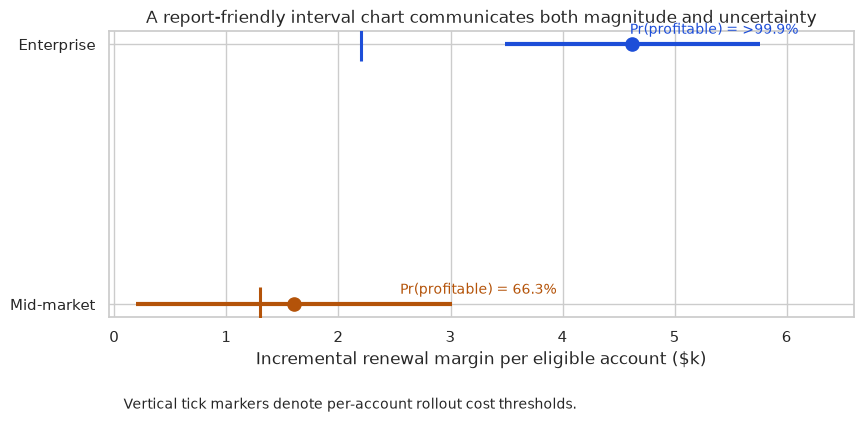

In [3]:
# Use an interval chart to show both magnitude and uncertainty against each segment's cost threshold.
plot_df = segment_report.copy()
plot_df["segment_order"] = [1, 0]
plot_df["color"] = [COLORS["enterprise"], COLORS["mid"]]

annotation_x = {
    "Enterprise": 4.60,
    "Mid-market": 2.55,
}

# Place the two segments on separate rows so cost thresholds and uncertainty intervals do not overlap.
fig, ax = plt.subplots(figsize=(8.8, 4.6))

for _, row in plot_df.iterrows():
    ax.hlines(
        y=row["segment_order"],
        xmin=row["ci95_low_k"],
        xmax=row["ci95_high_k"],
        color=row["color"],
        linewidth=3,
    )
    ax.scatter(
        row["posterior_mean_k"],
        row["segment_order"],
        color=row["color"],
        s=90,
        zorder=3,
    )
    ax.scatter(
        row["rollout_cost_k"],
        row["segment_order"],
        color=row["color"],
        marker="|",
        s=600,
        linewidths=2.2,
        zorder=4,
    )
    ax.text(
        annotation_x[row["segment"]],
        row["segment_order"] + 0.04,
        f"Pr(profitable) = {fmt_prob(row['Pr(segment profitable)'])}",
        fontsize=10,
        color=row["color"],
    )

ax.set_yticks([0, 1])
ax.set_yticklabels(["Mid-market", "Enterprise"])
ax.set_xlabel("Incremental renewal margin per eligible account ($k)")
ax.set_title("A report-friendly interval chart communicates both magnitude and uncertainty")
ax.set_xlim(-0.05, 6.6)
ax.text(
    0.02,
    -0.32,
    "Vertical tick markers denote per-account rollout cost thresholds.",
    transform=ax.transAxes,
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 3. Different Stakeholders Need Different Lead Metrics

The same analysis should not be narrated identically to every audience.

| Audience | Their first question | Lead metric | Common reporting mistake |
| --- | --- | --- | --- |
| Executive sponsor | What should we do next quarter? | Recommended action and expected business value | Leading with statistical jargon before stating the decision |
| Finance partner | What is the downside if we are wrong? | Probability of negative value, conservative scenario, and opportunity cost | Reporting only the mean |
| Operations lead | What changes operationally if we launch? | Segment scope, guardrails, and monitoring triggers | Giving an effect estimate with no implementation conditions |
| Technical reviewer | How fragile is the conclusion? | Assumptions, interval estimates, model limitations, and sensitivity points | Hiding uncertainty to sound decisive |

Good stakeholder reporting is not “dumbing down” the analysis. It is choosing the first page correctly.


## 4. Decision-Ready Action Table

We now compare four candidate actions:

1. **No rollout**
2. **Enterprise only**
3. **Enterprise + Mid-market now**
4. **Enterprise now + a 200-account Mid-market follow-up pilot**

The final option carries forward the best study design from notebook 14. To compare it in decision units, we treat the notebook 14 net EVSI estimate as an **additive planning benefit** for a learn-then-scale strategy. That is useful pedagogically, but it is still a modeling assumption and not a directly observed quarter-one cash flow.


In [4]:
# Simulate posterior predictive values for each candidate action.
DRAWS = 250_000

enterprise = pilot_summary.loc[pilot_summary["segment"] == "Enterprise"].iloc[0]
mid_market = pilot_summary.loc[pilot_summary["segment"] == "Mid-market"].iloc[0]

tau_enterprise = rng.normal(enterprise["posterior_mean_k"], enterprise["posterior_sd_k"], DRAWS)
tau_mid = rng.normal(mid_market["posterior_mean_k"], mid_market["posterior_sd_k"], DRAWS)

N_ENTERPRISE = int(enterprise["eligible_accounts_next_quarter"])
N_MID = int(mid_market["eligible_accounts_next_quarter"])
COST_ENTERPRISE = float(enterprise["rollout_cost_k"])
COST_MID = float(mid_market["rollout_cost_k"])
OVERHEAD_BOTH_M = 0.15

# Carry forward the corrected 200-account net EVSI estimate from notebook 14.
BEST_PILOT_N = 200
BEST_PILOT_GROSS_EVSI_M = 0.090
BEST_PILOT_STUDY_COST_M = 0.059
BEST_PILOT_NET_EVSI_M = BEST_PILOT_GROSS_EVSI_M - BEST_PILOT_STUDY_COST_M

value_none = np.zeros(DRAWS)
value_enterprise = N_ENTERPRISE * (tau_enterprise - COST_ENTERPRISE) / 1000
value_both = value_enterprise + N_MID * (tau_mid - COST_MID) / 1000 - OVERHEAD_BOTH_M
value_enterprise_plus_pilot = value_enterprise + BEST_PILOT_NET_EVSI_M

values = pd.DataFrame(
    {
        "No rollout": value_none,
        "Enterprise only": value_enterprise,
        "Enterprise + Mid-market now": value_both,
        "Enterprise now + Mid-market pilot": value_enterprise_plus_pilot,
    }
)

# Summarize each action in the quantities a stakeholder needs to compare.
action_rows = []
for action in values.columns:
    arr = values[action].to_numpy()
    action_rows.append(
        {
            "action": action,
            "expected_value_m": arr.mean(),
            "median_value_m": np.median(arr),
            "10th_percentile_m": np.quantile(arr, 0.10),
            "90th_percentile_m": np.quantile(arr, 0.90),
            "Pr(negative value)": np.mean(arr < 0),
            "certainty_equivalent_R=0.35_m": certainty_equivalent(arr, 0.35),
        }
    )

action_summary = pd.DataFrame(action_rows)
action_summary["risk_neutral_rank"] = action_summary["expected_value_m"].rank(
    ascending=False,
    method="dense",
).astype(int)
action_summary["balanced_rank"] = action_summary["certainty_equivalent_R=0.35_m"].rank(
    ascending=False,
    method="dense",
).astype(int)
action_summary = action_summary.sort_values("expected_value_m", ascending=False).reset_index(drop=True)

numeric_cols = [col for col in action_summary.columns if col != "action"]
action_summary[numeric_cols] = action_summary[numeric_cols].mask(
    np.isclose(action_summary[numeric_cols], 0.0),
    0.0,
)

# Keep the displayed table compact while preserving the full numeric action_summary for plots.
action_display = pd.DataFrame(
    {
        "Action": action_summary["action"],
        "Expected value ($M)": action_summary["expected_value_m"].map(lambda x: round(x, 3)),
        "Median ($M)": action_summary["median_value_m"].map(lambda x: round(x, 3)),
        "Central 80% range ($M)": action_summary.apply(
            lambda row: f"{row['10th_percentile_m']:.3f} to {row['90th_percentile_m']:.3f}",
            axis=1,
        ),
        "Pr(negative value)": action_summary.apply(
            lambda row: "0.0%"
            if row["action"] == "No rollout"
            else fmt_prob(row["Pr(negative value)"], exact_zero_label="<0.1%"),
            axis=1,
        ),
        "Certainty equivalent at R = $0.35M ($M)": action_summary["certainty_equivalent_R=0.35_m"].map(lambda x: round(x, 3)),
        "Risk-neutral rank": action_summary["risk_neutral_rank"].astype(int),
        "Balanced-risk rank (CE, R = $0.35M)": action_summary["balanced_rank"].astype(int),
    }
)

smart_display(action_display)

,Action,Expected value ($M),Median ($M),Central 80% range ($M),Pr(negative value),Certainty equivalent at R = $0.35M ($M),Risk-neutral rank,"Balanced-risk rank (CE, R = $0.35M)"
0,Enterprise + Mid-market now,0.971,0.972,0.101 to 1.838,7.6%,0.311,1,3
1,Enterprise now + Mid-market pilot,0.878,0.878,0.619 to 1.138,<0.1%,0.820,2,1
2,Enterprise only,0.847,0.847,0.588 to 1.107,<0.1%,0.789,3,2
3,No rollout,0.000,0.000,0.000 to 0.000,0.0%,0.000,4,4


The summary is deliberately action-first. Immediate full rollout has the highest expected value, but it also carries the visible downside probability. The Enterprise-plus-pilot option gives up some mean value while keeping the balanced-risk ranking strongest. That is the central reporting tension: the recommendation depends on whether leadership is optimizing mean value alone or value with downside protection.

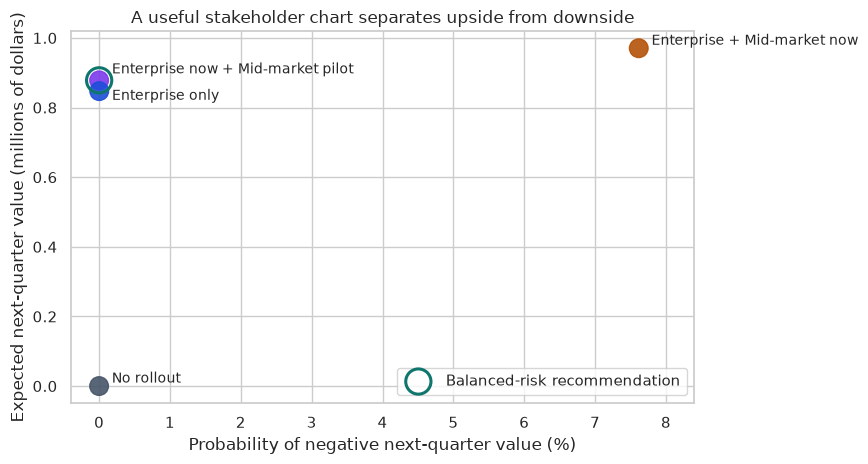

In [5]:
# Plot upside and downside together so the recommendation is not hidden inside a table.
risk_plot = action_summary.copy()

color_map = {
    "No rollout": COLORS["none"],
    "Enterprise only": COLORS["enterprise"],
    "Enterprise + Mid-market now": COLORS["mid"],
    "Enterprise now + Mid-market pilot": COLORS["pilot"],
}

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.scatter(
    100 * risk_plot["Pr(negative value)"],
    risk_plot["expected_value_m"],
    s=180,
    c=risk_plot["action"].map(color_map),
    alpha=0.9,
)

# Highlight the balanced-risk recommendation without changing the direct labels.
recommended = risk_plot.loc[risk_plot["balanced_rank"].eq(1)].iloc[0]
ax.scatter(
    100 * recommended["Pr(negative value)"],
    recommended["expected_value_m"],
    s=330,
    facecolors="none",
    edgecolors=COLORS["accent"],
    linewidths=2.2,
    label="Balanced-risk recommendation",
)

label_offsets = {
    "No rollout": (0.18, 0.01),
    "Enterprise only": (0.18, -0.025),
    "Enterprise now + Mid-market pilot": (0.18, 0.02),
    "Enterprise + Mid-market now": (0.18, 0.01),
}

for _, row in risk_plot.iterrows():
    dx, dy = label_offsets[row["action"]]
    ax.text(
        100 * row["Pr(negative value)"] + dx,
        row["expected_value_m"] + dy,
        row["action"],
        fontsize=10,
    )

ax.set_xlabel("Probability of negative next-quarter value (%)")
ax.set_ylabel("Expected next-quarter value (millions of dollars)")
ax.set_title("A useful stakeholder chart separates upside from downside")
ax.set_xlim(-0.4, 8.4)
ax.legend(frameon=True, loc="lower right")
plt.tight_layout()
plt.show()

This chart makes the tradeoff harder to miss. Immediate full rollout sits high on expected value but far to the right on downside probability. The pilot plan sits close to Enterprise-only on risk while adding a modest information value benefit. That visual separation is useful in a stakeholder meeting because it keeps the recommendation from sounding like a purely technical preference.

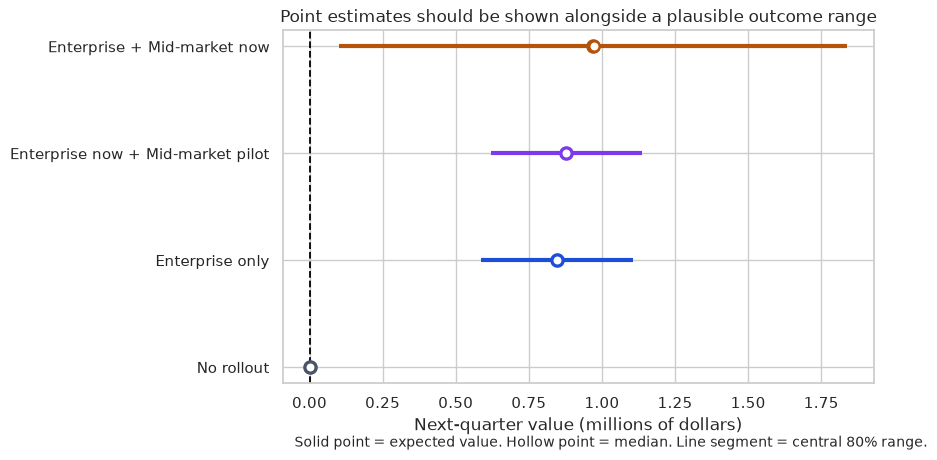

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
interval_plot = action_summary.copy().sort_values("expected_value_m", ascending=True)
y_pos = np.arange(len(interval_plot))

fig, ax = plt.subplots(figsize=(9.0, 4.8))

for i, (_, row) in enumerate(interval_plot.iterrows()):
    ax.hlines(i, row["10th_percentile_m"], row["90th_percentile_m"], color=color_map[row["action"]], linewidth=3)
    ax.scatter(row["expected_value_m"], i, color=color_map[row["action"]], s=90, zorder=3)
    ax.scatter(row["median_value_m"], i, color="white", edgecolor=color_map[row["action"]], s=55, zorder=4, linewidth=1.7)

ax.axvline(0, color="black", linestyle="--", linewidth=1.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(interval_plot["action"])
ax.set_xlabel("Next-quarter value (millions of dollars)")
ax.set_title("Point estimates should be shown alongside a plausible outcome range")
ax.text(
    0.02,
    -0.18,
    "Solid point = expected value. Hollow point = median. Line segment = central 80% range.",
    transform=ax.transAxes,
    fontsize=10,
)
plt.tight_layout()
plt.show()


The table and charts support three different defensible headlines because they correspond to different objective functions:

- **Risk-neutral planner:** full rollout now has the highest expected value.
- **Balanced planner (certainty-equivalent ranking with risk tolerance R = USD 0.35M):** enterprise now plus a targeted follow-up pilot dominates because it preserves most of the upside while sharply reducing downside exposure.
- **Very cautious planner:** enterprise-only rollout is still attractive even without the extra learning option.

The pilot-plan ranking also depends on a modeling approximation: we treat the notebook 14 net EVSI estimate as an additive planning benefit for a learn-then-scale strategy. That should be surfaced explicitly whenever the recommendation is presented.

## 5. Writing the Recommendation

A decision-ready recommendation usually needs five components:

1. **Action**: what should happen now,
2. **Magnitude**: what the benefit is expected to be,
3. **Uncertainty**: where the main remaining risk sits,
4. **Conditions**: what assumptions or guardrails matter,
5. **Next step**: what evidence or monitoring would change the recommendation.


In [7]:
# Convert the numeric comparison into three recommendation styles of increasing quality.
enterprise_only_row = action_summary.loc[action_summary["action"] == "Enterprise only"].iloc[0]
both_row = action_summary.loc[action_summary["action"] == "Enterprise + Mid-market now"].iloc[0]
pilot_row = action_summary.loc[action_summary["action"] == "Enterprise now + Mid-market pilot"].iloc[0]

bad_headline = "The pilot was statistically significant, so we should launch the workflow everywhere."
better_headline = (
    f"Enterprise results are clearly positive, while Mid-market remains promising but uncertain. "
    f"Launching Enterprise now is expected to add about {fmt_millions_text(enterprise_only_row['expected_value_m'])} next quarter, "
    f"and the broad Mid-market decision should remain open until additional evidence arrives."
)
best_headline = (
    f"For a moderately downside-sensitive decision-maker using a certainty-equivalent ranking with risk tolerance "
    f"R = USD 0.35M, launch Enterprise now and run a {BEST_PILOT_N}-account Mid-market follow-up pilot before broad release. "
    f"Enterprise-only rollout delivers about {fmt_millions_text(enterprise_only_row['expected_value_m'])} with "
    f"{fmt_prob(enterprise_only_row['Pr(negative value)'], exact_zero_label='<0.1%')} modeled downside in the current simulation, "
    f"whereas immediate full rollout reaches {fmt_millions_text(both_row['expected_value_m'])} on average but carries a "
    f"{fmt_prob(both_row['Pr(negative value)'])} chance of negative next-quarter value. "
    f"This learn-then-scale comparison also assumes that the notebook 14 net information value estimate of "
    f"{fmt_millions_text(BEST_PILOT_NET_EVSI_M)} can be treated as an additive planning benefit."
)

display(
    Markdown(
        f'''
### Weak Headline
> {bad_headline}

### Better Headline
> {better_headline}

### Decision-Ready Headline
> {best_headline}
        '''
    )
)


### Weak Headline
> The pilot was statistically significant, so we should launch the workflow everywhere.

### Better Headline
> Enterprise results are clearly positive, while Mid-market remains promising but uncertain. Launching Enterprise now is expected to add about USD 0.85M next quarter, and the broad Mid-market decision should remain open until additional evidence arrives.

### Decision-Ready Headline
> For a moderately downside-sensitive decision-maker using a certainty-equivalent ranking with risk tolerance R = USD 0.35M, launch Enterprise now and run a 200-account Mid-market follow-up pilot before broad release. Enterprise-only rollout delivers about USD 0.85M with <0.1% modeled downside in the current simulation, whereas immediate full rollout reaches USD 0.97M on average but carries a 7.6% chance of negative next-quarter value. This learn-then-scale comparison also assumes that the notebook 14 net information value estimate of USD 0.03M can be treated as an additive planning benefit.
        

The weak headline jumps from a statistical label to an action without naming the segment, uncertainty, or downside risk. The better headline identifies the main pattern, but still leaves the decision rule implicit. The decision-ready version states the action, objective function, expected value, downside tradeoff, and the modeling assumption behind the pilot strategy.

In [8]:
# Tailor the same statistical evidence for executive, operational, and technical audiences.
executive_brief = f'''
### Executive Brief

- **Recommended action under the balanced-risk view:** Launch Enterprise now and approve a targeted Mid-market follow-up pilot.
- **Decision lens:** This recommendation uses the certainty-equivalent ranking with a moderate risk tolerance of USD 0.35M alongside expected-value maximization.
- **Why:** This captures most of the upside while reducing exposure to the negative tail associated with an immediate full Mid-market rollout.
- **Expected value under this plan:** Approximately {fmt_millions_text(pilot_row['expected_value_m'])} next quarter.
- **Key risk:** Mid-market economics are still uncertain enough that an immediate full rollout retains a {fmt_prob(both_row['Pr(negative value)'])} chance of negative value.
- **Modeling note:** The pilot-plan comparison treats the notebook 14 net EVSI estimate as an additive planning benefit for a learn-then-scale strategy.
- **Decision trigger for broader launch:** Expand Mid-market after the additional pilot if the updated per-account uplift remains above cost with acceptable downside.
'''

operations_note = f'''
### Operations Note

- **Scope now:** Enable the workflow for Enterprise accounts only.
- **Do not scale blindly:** Hold Mid-market at pilot scope until the next readout.
- **Guardrails to monitor weekly:** adoption rate, queue times, exception rate, and any segment-specific quality degradation.
- **Escalation rule:** Pause expansion if realized savings or retention lift trends below the modeled 10th-percentile path for two consecutive review periods.
'''

technical_appendix = f'''
### Technical Appendix Summary

- Enterprise posterior mean uplift is {fmt_thousands_text(enterprise['posterior_mean_k'])} per eligible account with a 95% interval from {fmt_thousands_text(segment_report.loc[segment_report['segment'] == 'Enterprise', 'ci95_low_k'].iloc[0])} to {fmt_thousands_text(segment_report.loc[segment_report['segment'] == 'Enterprise', 'ci95_high_k'].iloc[0])}.
- Mid-market posterior mean uplift is {fmt_thousands_text(mid_market['posterior_mean_k'])} per eligible account with a 95% interval from {fmt_thousands_text(segment_report.loc[segment_report['segment'] == 'Mid-market', 'ci95_low_k'].iloc[0])} to {fmt_thousands_text(segment_report.loc[segment_report['segment'] == 'Mid-market', 'ci95_high_k'].iloc[0])}.
- Immediate full rollout ranks first only under a pure expected-value objective.
- The balanced recommendation is conditional on a certainty-equivalent objective with risk tolerance R = USD 0.35M.
- The pilot strategy uses notebook 14's net EVSI estimate as an additive planning term; that is a modeling approximation and not a directly observed quarter-one cash flow.
'''

display(Markdown(executive_brief))
display(Markdown(operations_note))
display(Markdown(technical_appendix))


### Executive Brief

- **Recommended action under the balanced-risk view:** Launch Enterprise now and approve a targeted Mid-market follow-up pilot.
- **Decision lens:** This recommendation uses the certainty-equivalent ranking with a moderate risk tolerance of USD 0.35M alongside expected-value maximization.
- **Why:** This captures most of the upside while reducing exposure to the negative tail associated with an immediate full Mid-market rollout.
- **Expected value under this plan:** Approximately USD 0.88M next quarter.
- **Key risk:** Mid-market economics are still uncertain enough that an immediate full rollout retains a 7.6% chance of negative value.
- **Modeling note:** The pilot-plan comparison treats the notebook 14 net EVSI estimate as an additive planning benefit for a learn-then-scale strategy.
- **Decision trigger for broader launch:** Expand Mid-market after the additional pilot if the updated per-account uplift remains above cost with acceptable downside.



### Operations Note

- **Scope now:** Enable the workflow for Enterprise accounts only.
- **Do not scale blindly:** Hold Mid-market at pilot scope until the next readout.
- **Guardrails to monitor weekly:** adoption rate, queue times, exception rate, and any segment-specific quality degradation.
- **Escalation rule:** Pause expansion if realized savings or retention lift trends below the modeled 10th-percentile path for two consecutive review periods.



### Technical Appendix Summary

- Enterprise posterior mean uplift is USD 4.62k per eligible account with a 95% interval from USD 3.48k to USD 5.76k.
- Mid-market posterior mean uplift is USD 1.60k per eligible account with a 95% interval from USD 0.19k to USD 3.01k.
- Immediate full rollout ranks first only under a pure expected-value objective.
- The balanced recommendation is conditional on a certainty-equivalent objective with risk tolerance R = USD 0.35M.
- The pilot strategy uses notebook 14's net EVSI estimate as an additive planning term; that is a modeling approximation and not a directly observed quarter-one cash flow.


## 6. Decision Register and Monitoring Plan

A recommendation is easier to trust when it is auditable after the fact. One lightweight way to do that is to attach a **decision register**. It records what was recommended, why, under which assumptions, and what would count as evidence that the decision should be revisited.


In [9]:
# Record the recommendation, evidence basis, assumptions, and monitoring responsibilities.
decision_register = pd.DataFrame(
    [
        {
            "field": "Decision owner",
            "entry": "VP, Customer Experience and Director of Applied Data Science",
        },
        {
            "field": "Current recommendation",
            "entry": "Launch Enterprise now; run a 200-account Mid-market follow-up pilot before broad release under the balanced-risk view.",
        },
        {
            "field": "Primary statistical basis",
            "entry": (
                f"Pure expected value ranks immediate full rollout first at {fmt_millions_text(both_row['expected_value_m'])}, "
                f"but under the certainty-equivalent lens with R = USD 0.35M the pilot plan ranks first; "
                f"immediate full rollout still carries {fmt_prob(both_row['Pr(negative value)'])} downside probability."
            ),
        },
        {
            "field": "Key uncertainty",
            "entry": "Mid-market uplift remains positive on average but too imprecise for a broad rollout under the balanced-risk objective.",
        },
        {
            "field": "Assumptions worth surfacing",
            "entry": (
                "Stable rollout costs, comparable traffic mix next quarter, no major spillovers from partial deployment, "
                "and use of notebook 14's net EVSI estimate as an additive planning benefit."
            ),
        },
        {
            "field": "What would change the recommendation",
            "entry": "Updated Mid-market evidence that lowers downside risk or materially raises expected uplift.",
        },
    ]
)

# Keep monitoring rules specific enough that the recommendation can be revisited after launch.
monitoring_plan = pd.DataFrame(
    [
        {"metric": "Enterprise realized value per eligible account", "review_rule": "Compare weekly against modeled 10th percentile path", "owner": "Finance + DS"},
        {"metric": "Workflow adoption rate", "review_rule": "Escalate if adoption is below launch expectation for 2 consecutive reviews", "owner": "Operations"},
        {"metric": "Mid-market pilot uplift", "review_rule": "Re-estimate posterior after 200 additional accounts", "owner": "DS"},
        {"metric": "Queue and service-quality guardrails", "review_rule": "Pause expansion if service degradation offsets projected gains", "owner": "Operations"},
    ]
)

smart_display(decision_register)
smart_display(monitoring_plan)

,field,entry
0,Decision owner,"VP, Customer Experience and Director of Applied Data Science"
1,Current recommendation,Launch Enterprise now; run a 200-account Mid-market follow-up pilot before broad release under the balanced-risk view.
2,Primary statistical basis,"Pure expected value ranks immediate full rollout first at USD 0.97M, but under the certainty-equivalent lens with R = USD 0.35M the pilot plan ranks first; immediate full rollout still carries 7.6% downside probability."
3,Key uncertainty,Mid-market uplift remains positive on average but too imprecise for a broad rollout under the balanced-risk objective.
4,Assumptions worth surfacing,"Stable rollout costs, comparable traffic mix next quarter, no major spillovers from partial deployment, and use of notebook 14's net EVSI estimate as an additive planning benefit."
5,What would change the recommendation,Updated Mid-market evidence that lowers downside risk or materially raises expected uplift.


,metric,review_rule,owner
0,Enterprise realized value per eligible account,Compare weekly against modeled 10th percentile path,Finance + DS
1,Workflow adoption rate,Escalate if adoption is below launch expectation for 2 consecutive reviews,Operations
2,Mid-market pilot uplift,Re-estimate posterior after 200 additional accounts,DS
3,Queue and service-quality guardrails,Pause expansion if service degradation offsets projected gains,Operations


The decision register turns the statistical recommendation into an operational commitment. It records what action is being taken, what evidence supports it, what could go wrong, and what the team should monitor after launch.

## 7. Reporting Checklist

Before sending a memo or presenting a slide, ask:

| Question | Why it matters |
| --- | --- |
| Did I state the action first? | Stakeholders should not have to reverse-engineer the recommendation. |
| Did I quantify the effect in business units? | Decisions are usually made in dollars, counts, rates, time, or risk thresholds. |
| Did I report both a point estimate and uncertainty? | Overconfident summaries age badly. |
| Did I separate expected upside from downside risk? | Means alone can hide unacceptable tails. |
| Did I state the assumptions that support the recommendation? | Recommendations without assumptions cannot be audited. |
| Did I explain what future evidence would change the recommendation? | Good reporting keeps learning alive while keeping uncertainty visible. |


<!-- real-data-companion-course01 -->
## Real-Data Companion: A Stakeholder-Ready RAND HIE Readout

The final reporting task is to turn statistical evidence into a decision-facing narrative. RAND HIE is useful because it is a real randomized health-insurance experiment, but the companion uses only a compact teaching contrast: outpatient physician visits under free care versus cost sharing.

The unit is a person-period record. The main outcome is `mdvis`, and the simplified grouping comes from `lncoins`. The companion assembles an evidence table, caveat register, and recommendation posture so the reader can see the difference between a statistical result and a stakeholder-ready recommendation.

The goal is not to write a full health-economics report. A complete report would discuss health outcomes, plan details, costs, subgroup equity, and transportability. The goal here is to show what a statistically honest real-data readout includes: the contrast, uncertainty, caveats, missing decision inputs, and a careful statement of what the evidence can and cannot support.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

In [10]:
# real-data-companion-course01
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from scipy import stats


def _find_project_root(start=Path.cwd()):
    """Find the portfolio root so shared helpers import reliably.

    Parameters
    ----------
    start : pathlib.Path
        Starting directory for the upward project-root search.

    Returns
    -------
    pathlib.Path
        Nearest parent containing ``notebooks/_shared``. If no parent matches, returns ``start``.

    Idea
    ----
    Rendered notebooks may execute from different working directories, so shared imports need a stable root.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rand_hie = load_statsmodels_randhie().copy()

    # Convert logged coinsurance into an interpretable grouping for the teaching readout.
    rand_hie["coinsurance"] = np.expm1(rand_hie["lncoins"]).round().clip(0, 100)
    rand_hie["plan_group"] = np.where(rand_hie["coinsurance"].eq(0), "Free care", "Cost sharing")
    free = rand_hie.loc[rand_hie["plan_group"].eq("Free care"), "mdvis"]
    cost = rand_hie.loc[rand_hie["plan_group"].eq("Cost sharing"), "mdvis"]

    # Summarize a simple difference in utilization while making the limitations explicit.
    diff = free.mean() - cost.mean()
    se = np.sqrt(free.var(ddof=1) / len(free) + cost.var(ddof=1) / len(cost))
    ci = (diff - 1.96 * se, diff + 1.96 * se)
    p_value = stats.ttest_ind(free, cost, equal_var=False).pvalue

    evidence_table = pd.DataFrame(
        [
            {
                "stakeholder_question": "Does lower cost sharing change physician-visit use?",
                "evidence": f"Difference = {diff:.2f} visits",
                "uncertainty": f"Approx. 95% CI [{ci[0]:.2f}, {ci[1]:.2f}]",
                "decision_note": "Magnitude and downstream health value matter more than significance alone.",
            },
            {
                "stakeholder_question": "Is the outcome easy to model with simple normal assumptions?",
                "evidence": f"Median visits = {rand_hie['mdvis'].median():.0f}, 90th percentile = {rand_hie['mdvis'].quantile(0.90):.0f}",
                "uncertainty": "Count outcome with a long right tail",
                "decision_note": "Use count-model and bootstrap checks in a full analysis.",
            },
            {
                "stakeholder_question": "Can we make a clean causal claim from this companion alone?",
                "evidence": "RAND HIE is randomized, but this lecture uses a simplified contrast",
                "uncertainty": "Plan details, health outcomes, and costs are not fully modeled here",
                "decision_note": "Report as a teaching readout, not a complete policy evaluation.",
            },
        ]
    )
    caveat_register = pd.DataFrame(
        [
            {"caveat": "Outcome scope", "why_it_matters": "Physician visits measure utilization, not health improvement by themselves."},
            {"caveat": "Cost model", "why_it_matters": "A rollout decision needs visit costs, health benefits, and budget constraints."},
            {"caveat": "Simplified grouping", "why_it_matters": "Free care versus any cost sharing hides finer plan variation."},
            {"caveat": "External validity", "why_it_matters": "A historical experiment may not transport directly to a current population."},
        ]
    )
    smart_display(evidence_table)
    smart_display(caveat_register)
    print(f"Welch test p-value for the simplified visit contrast: {p_value:.4g}")
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )

,stakeholder_question,evidence,uncertainty,decision_note
0,Does lower cost sharing change physician-visit use?,Difference = 0.58 visits,"Approx. 95% CI [0.45, 0.70]",Magnitude and downstream health value matter more than significance alone.
1,Is the outcome easy to model with simple normal assumptions?,"Median visits = 1, 90th percentile = 7",Count outcome with a long right tail,Use count-model and bootstrap checks in a full analysis.
2,Can we make a clean causal claim from this companion alone?,"RAND HIE is randomized, but this lecture uses a simplified contrast","Plan details, health outcomes, and costs are not fully modeled here","Report as a teaching readout, not a complete policy evaluation."


,caveat,why_it_matters
0,Outcome scope,"Physician visits measure utilization, not health improvement by themselves."
1,Cost model,"A rollout decision needs visit costs, health benefits, and budget constraints."
2,Simplified grouping,Free care versus any cost sharing hides finer plan variation.
3,External validity,A historical experiment may not transport directly to a current population.


Welch test p-value for the simplified visit contrast: 4.527e-20


<!-- real-data-companion-course01 -->
A professional readout separates evidence from action. The real-data table reports the contrast, the uncertainty, the caveats, and the missing pieces. That is the posture this course is trying to build: clear enough to support a decision, careful enough not to outrun the evidence.

## What to Remember

- A recommendation should report **action, magnitude, uncertainty, conditions, and next step**.
- The same statistical result should be narrated differently for executives, operators, and technical reviewers.
- Absolute business impact is often more decision-relevant than a standalone test result.
- Good reporting makes downside risk explicit so it is not buried inside technical appendices.
- A decision register and monitoring plan make statistical recommendations easier to trust and revise.

This concludes the first statistical inference course by taking us from formal inference all the way to written for stakeholders statistical decision support.


## References

- Holmes, J., Angus, C., & Meier, P. (2019). *How should we set consumption thresholds for low risk drinking guidelines? Achieving objectivity and transparency using evidence, expert judgement and pragmatism.* *Addiction, 114*(4), 590-600. [https://doi.org/10.1111/add.14381](https://doi.org/10.1111/add.14381)
- Patten, S. B., & Streiner, D. L. (2021). *P values and confidence intervals.* *The Canadian Journal of Psychiatry, 66*(4), 421-422. [https://doi.org/10.1177/0706743720962277](https://doi.org/10.1177/0706743720962277)
- Trowman, R., Powers, A., & Ollendorf, D. A. (2021). *Considering and communicating uncertainty in health technology assessment.* *International Journal of Technology Assessment in Health Care, 37*(1). [https://doi.org/10.1017/S0266462321000453](https://doi.org/10.1017/S0266462321000453)
- Wasserstein, R., & Lazar, N. A. (2016). *The ASA Statement on p-Values: Context, Process, and Purpose.* *The American Statistician, 70*(2), 129-133. [https://doi.org/10.1080/00031305.2016.1154108](https://doi.org/10.1080/00031305.2016.1154108)
- Wentzensen, N., & Clarke, M. A. (2017). *From clinical epidemiology to practice recommendations: Knowledge gaps and uncertainty in the management of anal precancers.* *Cancer, 123*(23), 4530-4534. [https://doi.org/10.1002/cncr.31033](https://doi.org/10.1002/cncr.31033)
